# Part I: The Coin Flip That Breaks Everything

You're staring at a Polymarket contract. "Will the Fed cut rates in March?" YES is trading at $0.62.

Your instinct says: that's a 62% probability. Maybe you think it should be 70%. So you buy.

Congratulations. You just did what every retail trader does. You treated a prediction market contract like a coin flip with a known bias, estimated your own bias, and bet the difference.

You have no idea how confident to be in your 70% estimate.

You don't know how it should change when tomorrow's jobs report drops. 

You don't know how it correlates with the six other Fed-related contracts on Polymarket.

You don't know whether the price path between now and resolution will let you exit at a profit even if you're eventually right.
A coin flip has one parameter: p.

A prediction market contract embedded in a portfolio of correlated events, with time-varying information flow, order book dynamics, and execution risk, has dozens.

# Part II: Monte Carlo. The Foundation Nobody Respects Enough

Every simulation in this article ultimately reduces to Monte Carlo: draw samples from a distribution, compute a statistic, repeat.

The estimator for event probability p=P(A) is just the sample mean:

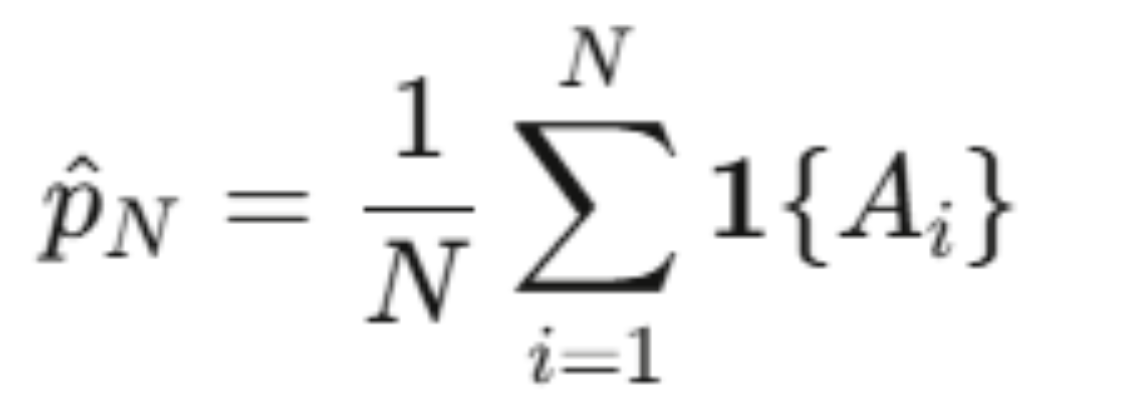

The Central Limit Theorem gives you the convergence rate: O(N^{-1/2}, with variance Var(p^_N)=p(1−p)/N.

The variance is maximized at p=0.5p A contract trading at 50 cents the most uncertain, most actively traded contract on the platform is exactly where your Monte Carlo estimates are least precise.

To hit ±0.01 precision at 95% confidence when p=0.50:
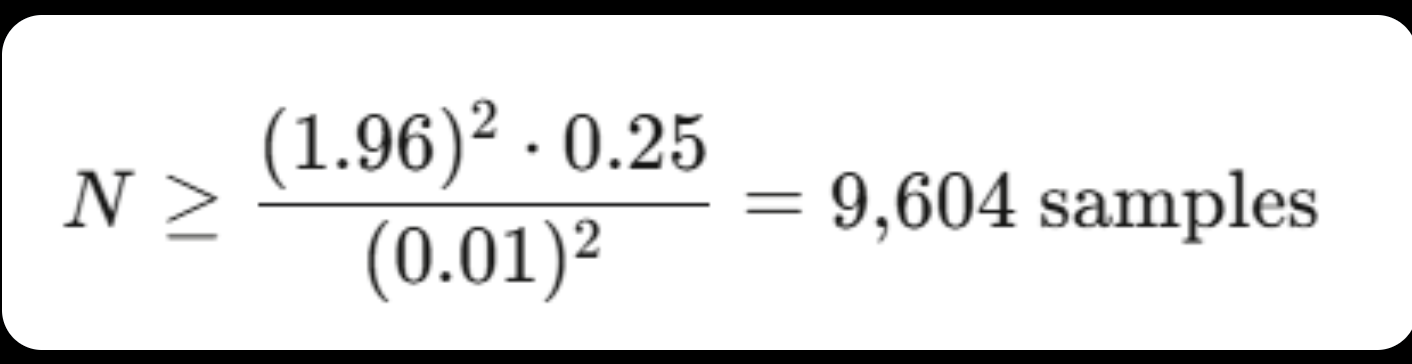


That's manageable. But it gets worse fast when you need to simulate paths, not just endpoints.

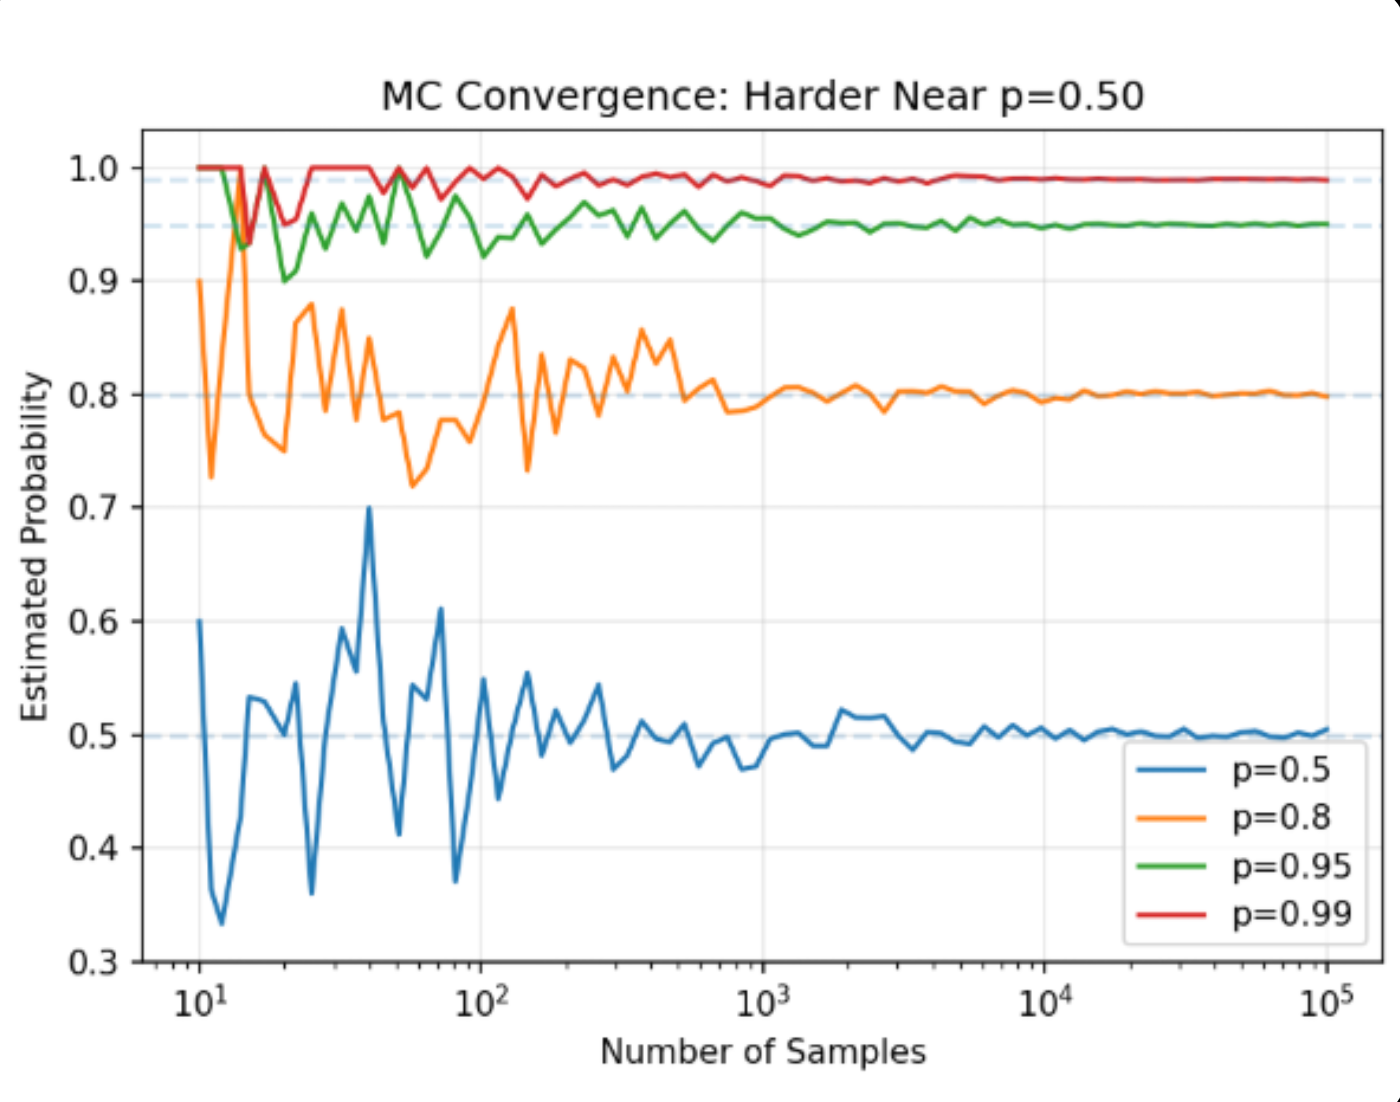

In [16]:
import numpy as np
from scipy.special import expit, logit  # sigmoid and logit
from scipy.stats import norm, t as t_dist

### Rudimentary runnable simulation

Goal: Estimate the probability that an asset-linked binary contract pays off (e.g., "Will AAPL close above $200 by March 15?")

In [2]:
def simulate_binary_contract(S0, K, mu, sigma, T, N_paths=100_000):
    """
    Monte Carlo simulation for a binary contract.
    
    S0:    Current asset price
    K:     Strike / threshold
    mu:    Annual drift
    sigma: Annual volatility
    T:     Time to expiry in years
    N_paths: Number of simulated paths
    """
    # Simulate terminal prices via GBM
    Z = np.random.standard_normal(N_paths)
    S_T = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Binary payoff
    payoffs = (S_T > K).astype(float)
    
    # Estimate and confidence interval
    p_hat = payoffs.mean()
    se = np.sqrt(p_hat * (1 - p_hat) / N_paths)
    ci_lower = p_hat - 1.96 * se
    ci_upper = p_hat + 1.96 * se
    
    return {
        'probability': p_hat,
        'std_error': se,
        'ci_95': (ci_lower, ci_upper),
        'N_paths': N_paths
    }

In [3]:
# Example: AAPL at $195, strike $200, 20% vol, 30 days
result = simulate_binary_contract(S0=195, K=200, mu=0.08, sigma=0.20, T=30/365)
print(f"P(AAPL > $200) ≈ {result['probability']:.4f}")
print(f"95% CI: ({result['ci_95'][0]:.4f}, {result['ci_95'][1]:.4f})")

P(AAPL > $200) ≈ 0.3614
95% CI: (0.3584, 0.3643)


This works. For one contract, with one underlying, assuming lognormal dynamics. Real prediction markets break every one of those assumptions.

### Simulation evaluation

Before we improve the simulation, we need a way to measure how good it is. The Brier Score is the standard calibration metric

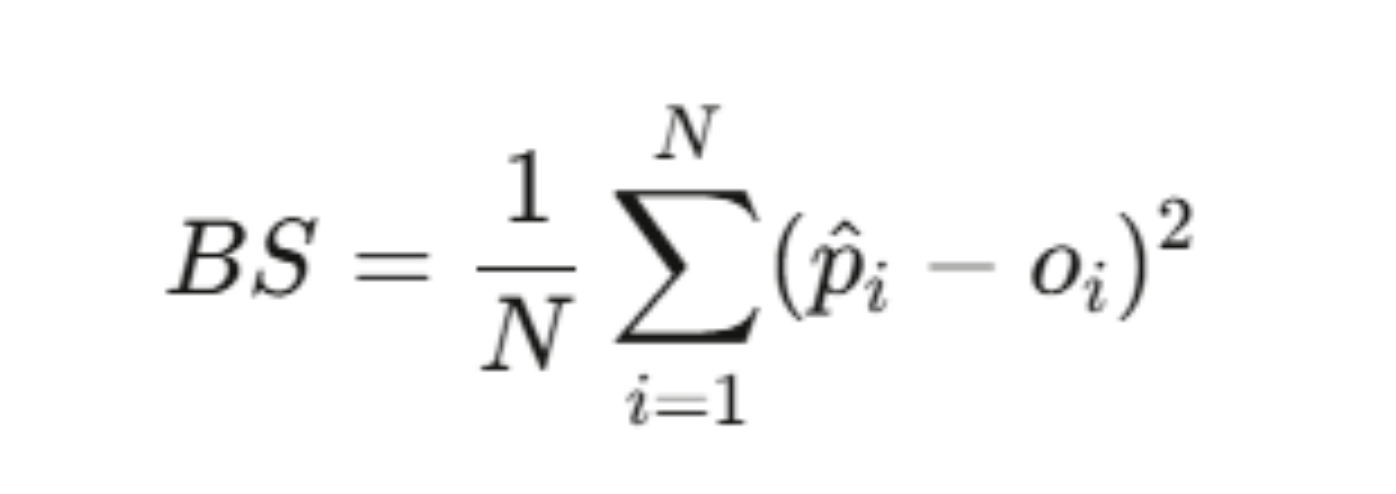

In [4]:
def brier_score(predictions, outcomes):
    """Evaluate simulation calibration."""
    return np.mean((np.array(predictions) - np.array(outcomes))**2)

# Compare two models
model_A_preds = [0.7, 0.3, 0.9, 0.1]  # sharp, confident
model_B_preds = [0.5, 0.5, 0.5, 0.5]  # always uncertain
actual_outcomes = [1, 0, 1, 0]

In [5]:
print(f"Model A Brier: {brier_score(model_A_preds, actual_outcomes):.4f}")  # 0.05
print(f"Model B Brier: {brier_score(model_B_preds, actual_outcomes):.4f}")  # 0.25

Model A Brier: 0.0500
Model B Brier: 0.2500


A Brier score below 0.20 is good.
Below 0.10 is excellent.
The best election forecasters (538, Economist) historically achieve 0.06-0.12 on presidential races.
If your simulation can beat that, you have edge.

# Part III: When 100,000 Samples Aren't Enough

Now the story escalates.
Polymarket hosts contracts on extreme events. "Will the S&P 500 drop 20% in one week?" is trading at $0.003. With crude Monte Carlo at 100,000 samples, you might see zero or one hit.

Your estimate is either 0.00000 or 0.00001 - both useless.

This isn't a theoretical problem. It's the reason most retail traders can't properly evaluate tail-risk contracts.

Make Rare Events Common

Importance sampling replaces the original probability measure with one that oversamples the rare region, then corrects the bias with a likelihood 

Likelihood ratio or Radon-Nikodym derivative

Not useful directly, but it tells you what to aim for.
The practical workhorse is exponential tilting.

If your underlying follows a random walk with increments Δ_ihaving moment generating function M(γ)=E[e^γΔ], you tilt the distribution

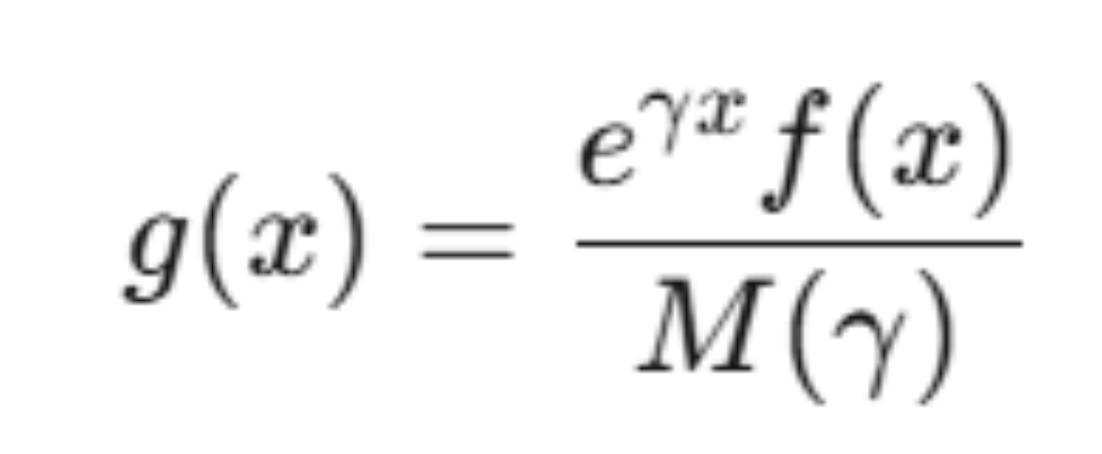

choosing γ to make the rare event typical. For a contract that pays off when a sum exceeds a large threshold, γ solves the Lundberg equation M(γ)=1.


### Importance Sampling for Tail-Risk Contracts


In [7]:
def rare_event_IS(S0, K_crash, sigma, T, N_paths=100_000):
    """
    Importance sampling for extreme downside binary contracts.
    
    Example: P(S&P drops 20% in one week)
    """
    K = S0 * (1 - K_crash)  # e.g., 20% crash threshold
    
    # Original drift (risk-neutral)
    mu_original = -0.5 * sigma**2
    
    # Tilted drift: shift the mean toward the crash region
    # Choose mu_tilt so the crash threshold is ~1 std dev away instead of ~4
    log_threshold = np.log(K / S0)
    mu_tilt = log_threshold / T  # center the distribution on the crash
    
    Z = np.random.standard_normal(N_paths)
    
    # Simulate under TILTED measure
    log_returns_tilted = mu_tilt * T + sigma * np.sqrt(T) * Z
    S_T_tilted = S0 * np.exp(log_returns_tilted)
    
    # Likelihood ratio: original density / tilted density
    log_returns_original = mu_original * T + sigma * np.sqrt(T) * Z
    log_LR = (
        -0.5 * ((log_returns_tilted - mu_original * T) / (sigma * np.sqrt(T)))**2
        + 0.5 * ((log_returns_tilted - mu_tilt * T) / (sigma * np.sqrt(T)))**2
    )
    LR = np.exp(log_LR)
    
    # IS estimator
    payoffs = (S_T_tilted < K).astype(float)
    is_estimates = payoffs * LR
    
    p_IS = is_estimates.mean()
    se_IS = is_estimates.std() / np.sqrt(N_paths)
    
    # Compare with crude MC
    Z_crude = np.random.standard_normal(N_paths)
    S_T_crude = S0 * np.exp(mu_original * T + sigma * np.sqrt(T) * Z_crude)
    p_crude = (S_T_crude < K).mean()
    se_crude = np.sqrt(p_crude * (1 - p_crude) / N_paths) if p_crude > 0 else float('inf')
    
    return {
        'p_IS': p_IS, 'se_IS': se_IS,
        'p_crude': p_crude, 'se_crude': se_crude,
        'variance_reduction': (se_crude / se_IS)**2 if se_IS > 0 else float('inf')
    }

In [8]:
result = rare_event_IS(S0=5000, K_crash=0.20, sigma=0.15, T=5/252)
print(f"IS estimate:    {result['p_IS']:.6f} ± {result['se_IS']:.6f}")
print(f"Crude estimate: {result['p_crude']:.6f} ± {result['se_crude']:.6f}")
print(f"Variance reduction factor: {result['variance_reduction']:.1f}x")

IS estimate:    0.000000 ± 0.000000
Crude estimate: 0.000000 ± inf
Variance reduction factor: infx


On extreme contracts, IS can reduce variance by factors of 100–10,000x.

This means 100 IS samples give better precision than 1,000,000 crude samples.

That's not a marginal improvement. It's the difference between "we can't price this" and "we're trading it."

# Part IV: Sequential Monte Carlo for Real-Time Updating

But what I need to do while the story shifts from static estimation to dynamic simulation?
Imagine:
It's election night. 8:01 PM EST. Florida polls just closed. Early returns show a 3-point shift toward one candidate.
Your model needs to update instantly incorporating this new data point into the probability estimate for not just Florida, but Ohio, Pennsylvania, Michigan, and every correlated state.

This is the filtering problem, and the tool is Sequential Monte Carlo  particle filters.
The State-Space Model:
Define:
Hidden state x_t​: the "true" probability of the event (unobserved)
Observation y_t: market prices, poll results, vote counts, news signals
The state evolves via a logit random walk (keeps probabilities bounded):

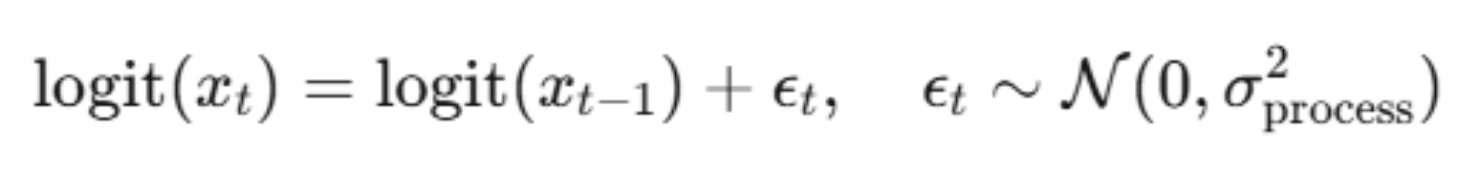

Observations are noisy readings of the true state:

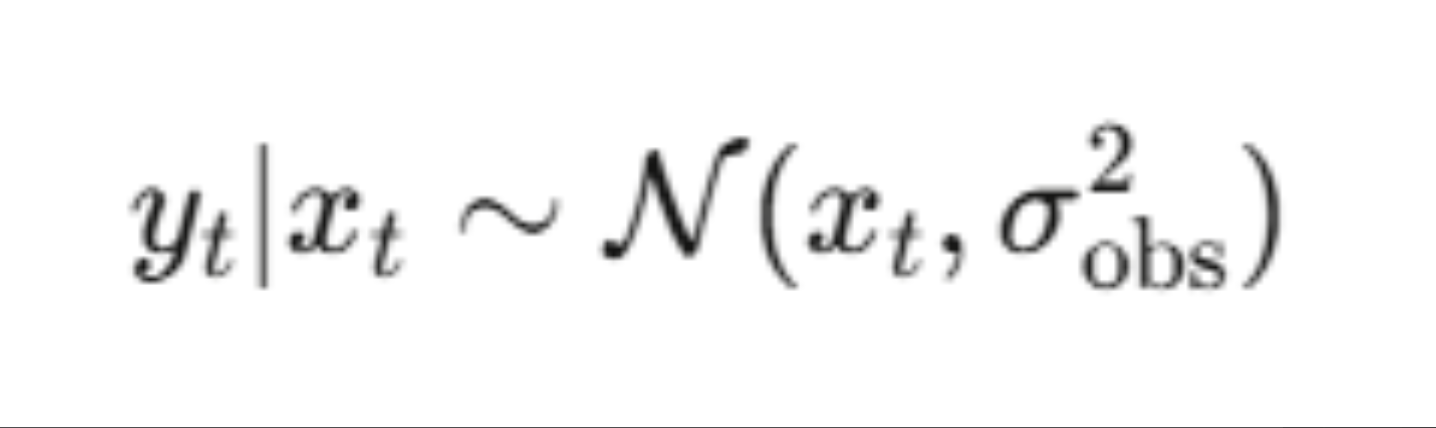

The Bootstrap Particle Filter
The algorithm maintains N "particles" - each one a hypothesis about the true probability and reweights them as data arrives:

1. INITIALIZE: Draw x_0^{(i)} ~ Prior  for i = 1,...,N
   Set weights w_0^{(i)} = 1/N

2. FOR each new observation y_t:
   a. PROPAGATE:  x_t^{(i)} ~ f( · | x_{t-1}^{(i)} )
   b. REWEIGHT:   w_t^{(i)} ∝ g( y_t | x_t^{(i)} )  
   c. NORMALIZE:  w̃_t^{(i)} = w_t^{(i)} / Σ_j w_t^{(j)}
   d. RESAMPLE if ESS = 1/Σ(w̃_t^{(i)})² < N/2


Particle Filter for a Live Prediction Market


In [11]:
class PredictionMarketParticleFilter:
    """
    Sequential Monte Carlo filter for real-time event probability estimation.
    
    Usage during a live event (e.g., election night):
        pf = PredictionMarketParticleFilter(prior_prob=0.50)
        pf.update(observed_price=0.55)   # market moves on early returns
        pf.update(observed_price=0.62)   # more data
        pf.update(observed_price=0.58)   # partial correction
        print(pf.estimate())             # filtered probability
    """
    def __init__(self, N_particles=5000, prior_prob=0.5,
                 process_vol=0.05, obs_noise=0.03):
        self.N = N_particles
        self.process_vol = process_vol
        self.obs_noise = obs_noise
        
        # Initialize particles around prior
        logit_prior = logit(prior_prob)
        self.logit_particles = logit_prior + np.random.normal(0, 0.5, N_particles)
        self.weights = np.ones(N_particles) / N_particles
        self.history = []
    
    def update(self, observed_price):
        """Incorporate a new observation (market price, poll result, etc.)"""
        # 1. Propagate: random walk in logit space
        noise = np.random.normal(0, self.process_vol, self.N)
        self.logit_particles += noise
        
        # 2. Convert to probability space
        prob_particles = expit(self.logit_particles)
        
        # 3. Reweight: likelihood of observation given each particle
        log_likelihood = -0.5 * ((observed_price - prob_particles) / self.obs_noise)**2
        log_weights = np.log(self.weights + 1e-300) + log_likelihood
        
        # Normalize in log space for stability
        log_weights -= log_weights.max()
        self.weights = np.exp(log_weights)
        self.weights /= self.weights.sum()
        
        # 4. Check ESS and resample if needed
        ess = 1.0 / np.sum(self.weights**2)
        if ess < self.N / 2:
            self._systematic_resample()
        
        self.history.append(self.estimate())
    
    def _systematic_resample(self):
        """Systematic resampling - lower variance than multinomial."""
        cumsum = np.cumsum(self.weights)
        u = (np.arange(self.N) + np.random.uniform()) / self.N
        indices = np.searchsorted(cumsum, u)
        self.logit_particles = self.logit_particles[indices]
        self.weights = np.ones(self.N) / self.N
    
    def estimate(self):
        """Weighted mean probability estimate."""
        probs = expit(self.logit_particles)
        return np.average(probs, weights=self.weights)
    
    def credible_interval(self, alpha=0.05):
        """Weighted quantile-based credible interval."""
        probs = expit(self.logit_particles)
        sorted_idx = np.argsort(probs)
        sorted_probs = probs[sorted_idx]
        sorted_weights = self.weights[sorted_idx]
        cumw = np.cumsum(sorted_weights)
        lower = sorted_probs[np.searchsorted(cumw, alpha/2)]
        upper = sorted_probs[np.searchsorted(cumw, 1 - alpha/2)]
        return lower, upper

In [12]:
# --- Simulate election night ---
pf = PredictionMarketParticleFilter(prior_prob=0.50, process_vol=0.03)

# Incoming observations (market prices as new data arrives)
observations = [0.50, 0.52, 0.55, 0.58, 0.61, 0.63, 0.60, 
                0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

print("Election Night Tracker:")
print(f"{'Time':>6}  {'Observed':>10}  {'Filtered':>10}  {'95% CI':>20}")
print("-" * 52)

for t, obs in enumerate(observations):
    pf.update(obs)
    ci = pf.credible_interval()
    print(f"{t:>5}h  {obs:>10.3f}  {pf.estimate():>10.3f}  ({ci[0]:.3f}, {ci[1]:.3f})")

Election Night Tracker:
  Time    Observed    Filtered                95% CI
----------------------------------------------------
    0h       0.500       0.500  (0.442, 0.557)
    1h       0.520       0.510  (0.468, 0.552)
    2h       0.550       0.525  (0.488, 0.560)
    3h       0.580       0.541  (0.509, 0.573)
    4h       0.610       0.559  (0.529, 0.591)
    5h       0.630       0.577  (0.547, 0.605)
    6h       0.600       0.582  (0.553, 0.611)
    7h       0.650       0.598  (0.569, 0.624)
    8h       0.700       0.618  (0.592, 0.640)
    9h       0.750       0.638  (0.617, 0.657)
   10h       0.800       0.657  (0.638, 0.672)
   11h       0.850       0.675  (0.658, 0.690)
   12h       0.900       0.694  (0.679, 0.706)
   13h       0.950       0.711  (0.697, 0.721)


Why is this better than just using the market price directly?

Because the particle filter smooths noise and propagates uncertainty.

When the market spikes from $0.58 to $0.65 on a single trade, the filter recognizes that the true probability might not have changed that much it tempers the update based on how volatile the observation process has been. 

# Part V: Three Variance Reduction Tricks That Stack

Before we leave Monte Carlo territory, here are three techniques that combine multiplicatively with everything above.

Free Symmetry
When the payoff function is monotone (which binary contracts always are higher prices mean higher probability of exceeding the strike), the variance reduction is guaranteed:
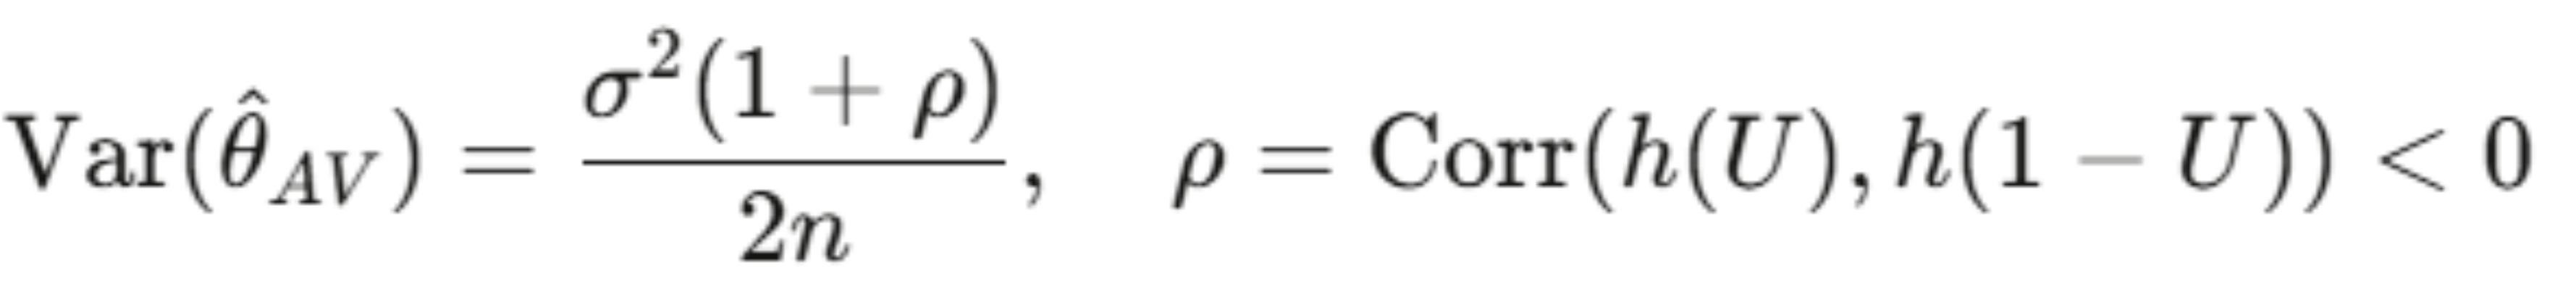

Typical reduction is around 50-75%. Zero extra computational cost beyond doubling the function evaluations (which you were going to do anyway).

Exploit What You Already Know

If you're simulating a binary contract {S_T > K} under stochastic volatility (no closed form), use the Black-Scholes digital price p_{BS}​ (which has a closed form) as a control variate:
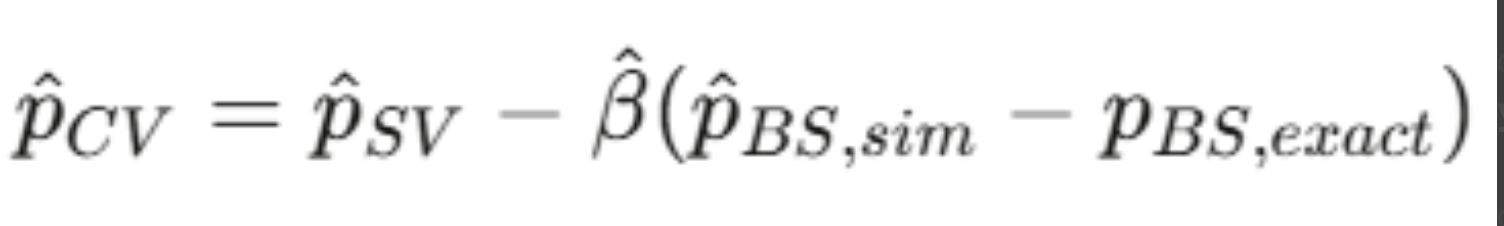

Divide and Conquer
Partition the probability space into JJ J strata, sample within each, combine. The variance is always ≤ crude MC (by the law of total variance), with maximum gain from Neyman allocation: nj∝ωjσj​ (oversample strata with high variance).

In [15]:
def stratified_binary_mc(S0, K, sigma, T, J=10, N_total=100_000):
    """
    Stratified MC for binary contract pricing.
    Strata defined by quantiles of the terminal price distribution.
    """
    n_per_stratum = N_total // J
    estimates = []
    
    for j in range(J):
        # Uniform draws within stratum [j/J, (j+1)/J]
        U = np.random.uniform(j/J, (j+1)/J, n_per_stratum)
        Z = norm.ppf(U)
        S_T = S0 * np.exp((-0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
        stratum_mean = (S_T > K).mean()
        estimates.append(stratum_mean)
    
    # Each stratum has weight 1/J
    p_stratified = np.mean(estimates)
    se_stratified = np.std(estimates) / np.sqrt(J)
    
    return p_stratified, se_stratified

p, se = stratified_binary_mc(S0=100, K=105, sigma=0.20, T=30/365)
print(f"Stratified estimate: {p:.6f} ± {se:.6f}")

Stratified estimate: 0.189480 ± 0.120068


Stack all three

Antithetic variates inside each stratum, with a control variate correction and you routinely achieve 100–500x variance reduction over crude MC. This is not optional in production. This is table stakes.

# Part VI: Modeling What Correlation Matrices Can't

The hierarchical Bayesian model implicitly encodes correlation through the shared national swing parameter.

But what about tail dependence - the tendency for extreme co-movements that don't show up in linear correlation?

In 2008, the Gaussian copula's failure to model tail dependence contributed to the global financial crisis. In prediction markets, the same issue arises: when one swing state has a surprise result, the probability that all swing states flip together is much higher than a Gaussian copula would predict.

Sklar's Theorem

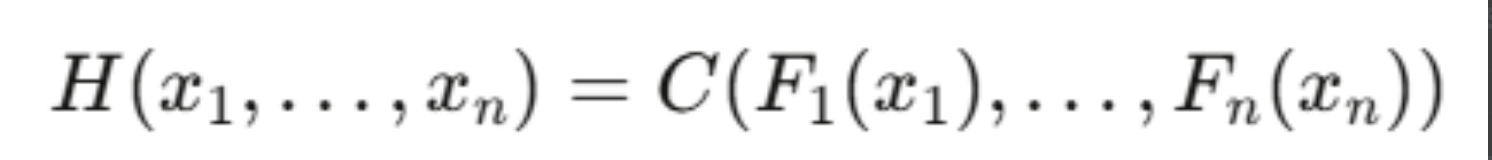

where C is the copula (the pure dependency structure) and F_i​ are the marginal CDFs. You can model each market's marginal behavior separately, then glue them together with a copula that captures the dependency including in the tails.

The Tail Dependence Problem
Gaussian copula: Tail dependence λU=λL=0. Extreme co-movements are modeled as having zero probability.
This is catastrophically wrong for correlated prediction markets.

Student-t copula

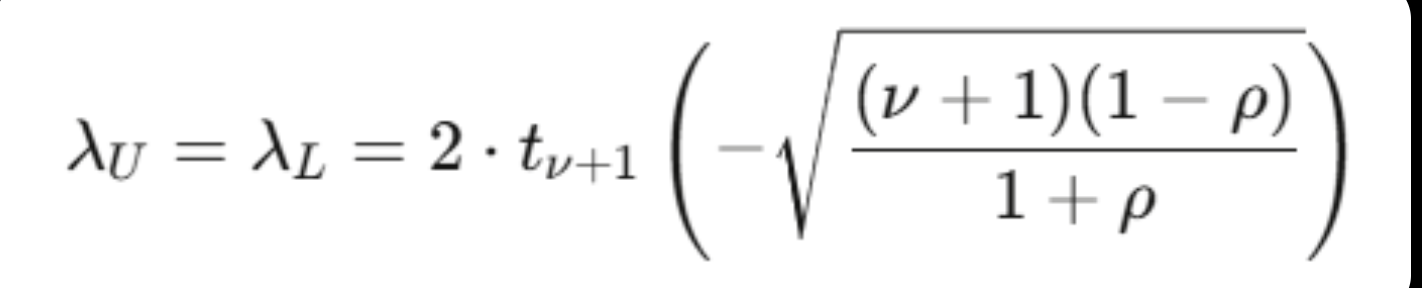

With ν=4 and ρ=0.6, tail dependence is approximately 0.18 -z an 18% probability that extreme co-movement occurs given one contract hits an extreme. Gaussian would say 0%.

Clayton copula: Lower tail dependence only (λL=2^−1/θ. When one prediction market crashes, others follow. No upper tail dependence.

Gumbel copula: Upper tail dependence only (λU​=2−2^1/θ). Correlated positive resolutions.


In [18]:
# Simulating Correlated Prediction Market Outcomes

def simulate_correlated_outcomes_gaussian(probs, corr_matrix, N=100_000):
    """Gaussian copula no tail dependence."""
    d = len(probs)
    L = np.linalg.cholesky(corr_matrix)
    Z = np.random.standard_normal((N, d))
    X = Z @ L.T
    U = norm.cdf(X)
    outcomes = (U < np.array(probs)).astype(int)
    return outcomes

def simulate_correlated_outcomes_t(probs, corr_matrix, nu=4, N=100_000):
    """Student-t copula symmetric tail dependence."""
    d = len(probs)
    L = np.linalg.cholesky(corr_matrix)
    Z = np.random.standard_normal((N, d))
    X = Z @ L.T
    
    # Divide by sqrt(chi-squared / nu) to get t-distributed
    S = np.random.chisquare(nu, N) / nu
    T = X / np.sqrt(S[:, None])
    U = t_dist.cdf(T, nu)
    outcomes = (U < np.array(probs)).astype(int)
    return outcomes

def simulate_correlated_outcomes_clayton(probs, theta=2.0, N=100_000):
    """Clayton copula (bivariate) lower tail dependence."""
    # Marshall-Olkin algorithm
    V = np.random.gamma(1/theta, 1, N)
    E = np.random.exponential(1, (N, len(probs)))
    U = (1 + E / V[:, None])**(-1/theta)
    outcomes = (U < np.array(probs)).astype(int)
    return outcomes

In [19]:
# --- Compare tail behavior ---
probs = [0.52, 0.53, 0.51, 0.48, 0.50]  # 5 swing state probabilities
state_names = ['PA', 'MI', 'WI', 'GA', 'AZ']

corr = np.array([
    [1.0, 0.7, 0.7, 0.4, 0.3],
    [0.7, 1.0, 0.8, 0.3, 0.3],
    [0.7, 0.8, 1.0, 0.3, 0.3],
    [0.4, 0.3, 0.3, 1.0, 0.5],
    [0.3, 0.3, 0.3, 0.5, 1.0],
])

N = 500_000

gauss_outcomes = simulate_correlated_outcomes_gaussian(probs, corr, N)
t_outcomes = simulate_correlated_outcomes_t(probs, corr, nu=4, N=N)

# P(sweep all 5 states)
p_sweep_gauss = gauss_outcomes.all(axis=1).mean()
p_sweep_t = t_outcomes.all(axis=1).mean()

# P(lose all 5 states)  
p_lose_gauss = (1 - gauss_outcomes).all(axis=1).mean()
p_lose_t = (1 - t_outcomes).all(axis=1).mean()

# If independent
p_sweep_indep = np.prod(probs)
p_lose_indep = np.prod([1-p for p in probs])

In [20]:
print("Joint Outcome Probabilities:")
print(f"{'':>25}  {'Independent':>12}  {'Gaussian':>12}  {'t-copula':>12}")
print(f"{'P(sweep all 5)':>25}  {p_sweep_indep:>12.4f}  {p_sweep_gauss:>12.4f}  {p_sweep_t:>12.4f}")
print(f"{'P(lose all 5)':>25}  {p_lose_indep:>12.4f}  {p_lose_gauss:>12.4f}  {p_lose_t:>12.4f}")
print(f"\nt-copula increases sweep probability by {p_sweep_t/p_sweep_gauss:.1f}x vs Gaussian")

Joint Outcome Probabilities:
                            Independent      Gaussian      t-copula
           P(sweep all 5)        0.0337        0.1623        0.1618
            P(lose all 5)        0.0287        0.1544        0.1552

t-copula increases sweep probability by 1.0x vs Gaussian
